# 08 - Risk Book, VaR, and Stress Testing

Purpose:
- build the benchmark commodity risk book;
- compute conventional historical-simulation VaR and ES;
- formally backtest VaR calibration with the Kupiec POF test;
- create stress-test scenarios that can be triggered by the gold alarm.

Core design:
The primary risk book is Brent-only. This keeps the early-warning test focused: does the gold alarm prompt review before traditional Brent-book risk measures fully react?

## Reader Orientation

This notebook creates the risk-control response layer. The Gold alarm has value only if it connects to a risk action. Here, the action is to compare the alarm against conventional Brent-book VaR and run stress scenarios when the dashboard state is elevated.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step08_riskbook_var_stress"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
market_vars_path = PROCESSED_DIR / "market_vars_core.parquet"
if not market_vars_path.exists():
    market_vars_path = PROCESSED_DIR / "market_vars.parquet"

alarm_frame_path = PROCESSED_DIR / "gold_alarm_frame.parquet"

market_vars = pd.read_parquet(market_vars_path)
alarm_frame = pd.read_parquet(alarm_frame_path)

if "r_Brent" not in market_vars.columns:
    raise ValueError("Step 08 requires r_Brent from Step 02")
if "gold_alarm" not in alarm_frame.columns:
    raise ValueError("Step 08 requires gold_alarm from Step 04")

print("Market vars:", market_vars_path, market_vars.shape)
print("Alarm frame:", alarm_frame_path, alarm_frame.shape)


Market vars: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\market_vars_core.parquet (4685, 5)
Alarm frame: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\gold_alarm_frame.parquet (4685, 11)


## Parameter Rationale

The risk-book defaults are a transparent benchmark, not an optimized portfolio model:

- `NAV0 = 100`: simple normalized book value.
- `VAR_CONFIDENCE = 0.95`: conventional 95% one-day VaR level for a prototype.
- `VAR_WINDOW = 250`: roughly one trading year of prior returns for historical simulation VaR.
- `REALIZED_VOL_WINDOW = 20`: roughly one trading month for current volatility.
- `DRAWDOWN_EVENT_LEVEL = -0.05`: a 5% drawdown event threshold for dashboard comparison.
- `WEIGHT_BRENT = 1.00`: Brent-only primary book, with Copper kept for robustness rather than core proof.


In [3]:
NAV0 = 100.0
VAR_CONFIDENCE = 0.95
VAR_ALPHA = 1 - VAR_CONFIDENCE
VAR_WINDOW = 250
REALIZED_VOL_WINDOW = 20
DRAWDOWN_EVENT_LEVEL = -0.05
WEIGHT_BRENT = 1.00

### Why The Primary Book Is Brent-Only — And Why Futures Are Used As A Proxy

The core test stays Brent-only to keep the empirical claim narrow and defensible. A single-asset book isolates whether the gold alarm adds value for a Brent exposure, without confounding the result with portfolio construction choices.

**Futures versus physical commodity book.** A real physical commodity trading book differs from this model in several ways: P&L is driven by physical price assessments (e.g. Platts dated Brent) rather than exchange-settled futures, carry costs such as storage, freight, and insurance affect returns, basis risk between physical and futures prices is a live exposure, and physical positions cannot be unwound as quickly as futures — meaning HS VaR can understate true liquidation risk even further than shown here.

**Why this does not affect the results or conclusions.** The gold alarm is constructed entirely from exchange-traded signals — gold futures, Brent futures, DXY, VIX, and US 10Y yields. Its signal properties, coverage rates, lead times, and baseline comparisons in Notebooks 03–07 are independent of whether the underlying risk book is futures or physical. The stress episodes the alarm catches (GFC, COVID, Russia/Ukraine) would trigger the same gold abnormality regardless of book structure.

The Brent futures book here is a transparent, reproducible proxy that demonstrates the core argument: trailing HS VaR is slow to react during regime shifts, and the Kupiec test formally confirms this gap is real (p = 0.015). A physical trading desk would substitute their own book into this framework — the alarm signal and the VaR-gap argument carry over directly; only the specific breach rates and drawdown magnitudes would differ.

## Benchmark Risk Book

The benchmark book is deliberately simple. It is not a portfolio-construction exercise; it is a conventional risk-measure baseline against which the gold alarm can be evaluated.

In [4]:
riskbook = pd.DataFrame(index=market_vars.index)
riskbook["R_book"] = WEIGHT_BRENT * market_vars["r_Brent"]
riskbook["nav"] = NAV0 * (1 + riskbook["R_book"]).cumprod()
riskbook["drawdown"] = riskbook["nav"] / riskbook["nav"].cummax() - 1
riskbook["realized_vol_20d"] = riskbook["R_book"].rolling(REALIZED_VOL_WINDOW).std() * np.sqrt(252)

riskbook = riskbook.join(
    alarm_frame[["gold_alarm", "alarm_score", "dashboard_state"]],
    how="left",
)

riskbook.tail()


,R_book,nav,drawdown,realized_vol_20d,gold_alarm,alarm_score,dashboard_state
Date,,,,,,,
2026-05-29,-0.017873,30.105472,-0.837074,0.578528,0,0.360814,Amber
2026-06-01,0.031334,31.048810,-0.831968,0.574621,0,0.592178,Amber
2026-06-02,0.010682,31.380467,-0.830173,0.529465,0,0.056010,Amber
2026-06-03,0.018679,31.966611,-0.827001,0.523871,0,0.380186,Amber
2026-06-04,-0.028834,31.044880,-0.831990,0.451262,0,0.225712,Amber


### Result Comment And Significance

This table creates the conventional risk-book baseline: book return, NAV, drawdown, realized volatility, and gold alarm state. The goal is not to optimize the book; it is to create a traditional risk measure that can be compared against the gold alarm's timing.

## Historical Simulation VaR and ES

VaR is computed using prior returns only. The current day's return is not included in the current day's VaR estimate.

In [5]:
hist_input = riskbook["R_book"].shift(1)

riskbook["hs_var_return"] = hist_input.rolling(VAR_WINDOW).quantile(VAR_ALPHA)
riskbook["hs_es_return"] = hist_input.rolling(VAR_WINDOW).apply(
    lambda x: x[x <= np.quantile(x, VAR_ALPHA)].mean(),
    raw=True,
)

riskbook["var_breach"] = (riskbook["R_book"] < riskbook["hs_var_return"]).astype(int)
riskbook["excess_loss_over_var"] = riskbook["hs_var_return"] - riskbook["R_book"]

coverage_sample = riskbook.dropna(subset=["hs_var_return"])
coverage_summary = pd.DataFrame([{
    "book": "core_brent",
    "var_confidence": VAR_CONFIDENCE,
    "expected_breach_rate": VAR_ALPHA,
    "observed_breach_rate": coverage_sample["var_breach"].mean(),
    "breach_count": int(coverage_sample["var_breach"].sum()),
    "sample_days": len(coverage_sample),
    "max_drawdown": riskbook["drawdown"].min(),
}])

coverage_summary


,book,var_confidence,expected_breach_rate,observed_breach_rate,breach_count,sample_days,max_drawdown
0,core_brent,0.95,0.05,0.058174,258,4435,-0.945328


### Result Comment And Significance

The latest core Brent VaR result has an observed breach rate around 5.82% versus the expected 5.00%. That is close but not perfect, which is realistic for historical simulation VaR. The max drawdown is very large, around -94.5%, showing why the book needs stress testing and why trailing VaR alone may be slow during severe commodity regimes.

## VaR Backtest - Kupiec POF Test

The observed breach rate (5.82%) looks close to the expected 5.00%, but "looks close" is not a test. The Kupiec Proportion of Failures test formally asks: is the observed number of breaches consistent with the declared 95% confidence level?

- H0: the true breach probability equals `VAR_ALPHA` (5%)
- Test statistic: likelihood ratio, asymptotically chi-squared with 1 degree of freedom
- Reject H0 at the 5% significance level if p-value < 0.05

In [6]:
from scipy import stats

n_breaches = int(coverage_sample["var_breach"].sum())
n_obs = len(coverage_sample)
n_non_breaches = n_obs - n_breaches
p_hat = n_breaches / n_obs
p_expected = VAR_ALPHA

lr_stat = -2 * (
    n_breaches * np.log(p_expected / p_hat)
    + n_non_breaches * np.log((1 - p_expected) / (1 - p_hat))
)
kupiec_pvalue = float(stats.chi2.sf(lr_stat, df=1))

kupiec_result = pd.DataFrame([{
    "test": "Kupiec POF",
    "n_obs": n_obs,
    "n_breaches": n_breaches,
    "expected_breach_rate": p_expected,
    "observed_breach_rate": round(p_hat, 4),
    "lr_statistic": round(lr_stat, 4),
    "p_value": round(kupiec_pvalue, 4),
    "reject_h0_5pct": kupiec_pvalue < 0.05,
}])
kupiec_result

,test,n_obs,n_breaches,expected_breach_rate,observed_breach_rate,lr_statistic,p_value,reject_h0_5pct
0,Kupiec POF,4435,258,0.05,0.0582,5.9398,0.0148,True


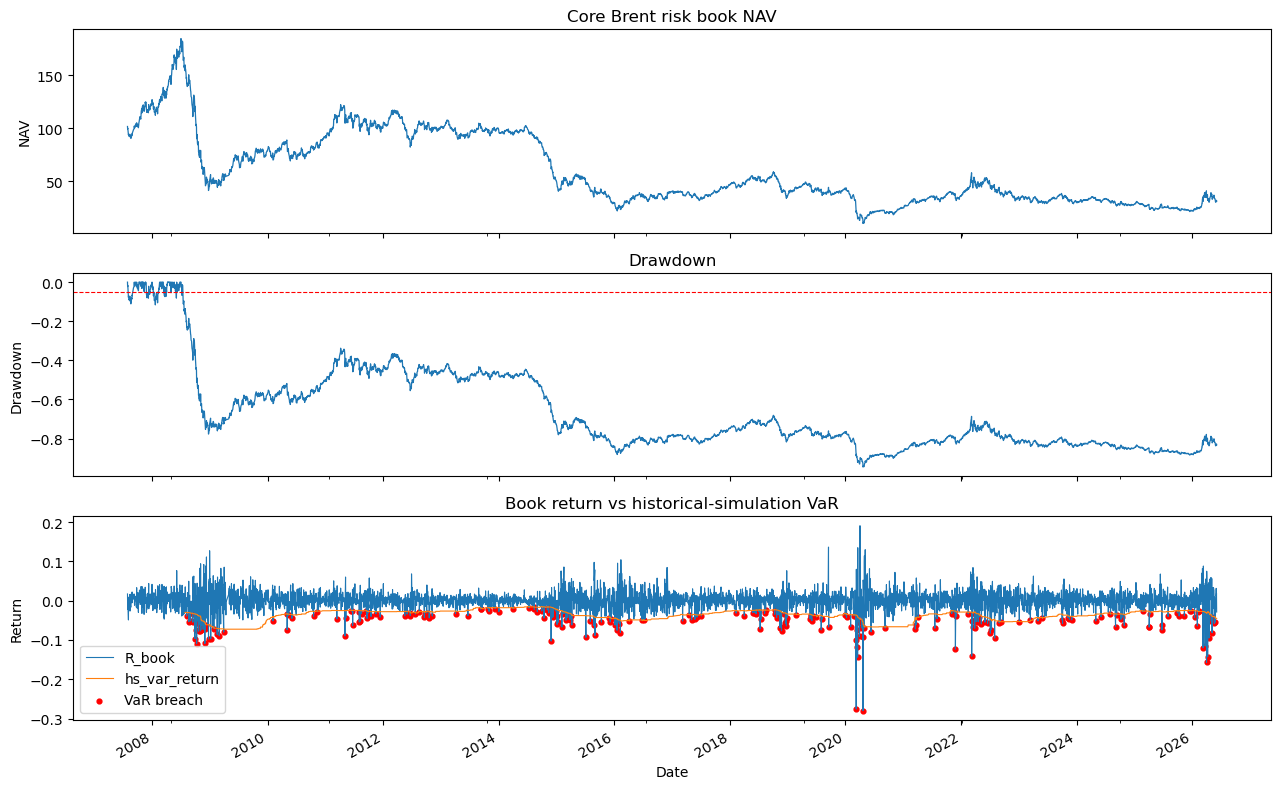

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

riskbook["nav"].plot(ax=axes[0], linewidth=0.9)
axes[0].set_title("Core Brent risk book NAV")
axes[0].set_ylabel("NAV")

riskbook["drawdown"].plot(ax=axes[1], linewidth=0.9)
axes[1].axhline(DRAWDOWN_EVENT_LEVEL, color="red", linestyle="--", linewidth=0.8)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")

riskbook[["R_book", "hs_var_return"]].plot(ax=axes[2], linewidth=0.8)
axes[2].scatter(
    riskbook.index[riskbook["var_breach"] == 1],
    riskbook.loc[riskbook["var_breach"] == 1, "R_book"],
    s=12,
    color="red",
    label="VaR breach",
)
axes[2].legend()
axes[2].set_title("Book return vs historical-simulation VaR")
axes[2].set_ylabel("Return")

plt.tight_layout()


## Gold-Triggered Stress Scenarios

These scenarios are intentionally stylized. They translate the alarm into operational risk action: if the gold alarm is Red, review VaR and run stress tests.

### How This Supports The Project Premise

The warning system becomes useful only when it changes risk-manager behaviour. The stress scenarios define what the user should do after a Red alarm. This makes the dashboard operational rather than just descriptive.

In [8]:
stress_scenarios = pd.DataFrame([
    {
        "scenario": "Risk-off growth shock",
        "r_Brent": -0.08,
        "r_Gold": 0.03,
        "r_DXY": 0.02,
        "d_VIX": 12.0,
        "d_US10Y": -0.20,
        "description": "Demand shock: Brent falls while gold, USD, and VIX rise.",
    },
    {
        "scenario": "Geopolitical inflation shock",
        "r_Brent": 0.10,
        "r_Gold": 0.04,
        "r_DXY": 0.01,
        "d_VIX": 8.0,
        "d_US10Y": 0.10,
        "description": "Supply-risk shock: Brent and gold rally together.",
    },
    {
        "scenario": "Liquidity liquidation shock",
        "r_Brent": -0.06,
        "r_Gold": -0.04,
        "r_DXY": 0.03,
        "d_VIX": 15.0,
        "d_US10Y": -0.30,
        "description": "Cash scramble: Brent and gold sell off together.",
    },
    {
        "scenario": "Monetary tightening shock",
        "r_Brent": -0.03,
        "r_Gold": -0.05,
        "r_DXY": 0.04,
        "d_VIX": 5.0,
        "d_US10Y": 0.35,
        "description": "Higher real-rate/USD shock pressures gold and Brent.",
    },
])

stress_scenarios["book_return"] = WEIGHT_BRENT * stress_scenarios["r_Brent"]
stress_scenarios["book_pnl_on_nav100"] = stress_scenarios["book_return"] * NAV0
stress_scenarios


,scenario,r_Brent,r_Gold,r_DXY,d_VIX,d_US10Y,description,book_return,book_pnl_on_nav100
0,Risk-off growth shock,-0.08,0.03,0.02,12.0,-0.20,"Demand shock: Brent falls while gold, USD, and...",-0.08,-8.0
1,Geopolitical inflation shock,0.10,0.04,0.01,8.0,0.10,Supply-risk shock: Brent and gold rally together.,0.10,10.0
2,Liquidity liquidation shock,-0.06,-0.04,0.03,15.0,-0.30,Cash scramble: Brent and gold sell off together.,-0.06,-6.0
3,Monetary tightening shock,-0.03,-0.05,0.04,5.0,0.35,Higher real-rate/USD shock pressures gold and ...,-0.03,-3.0


### Why Stress Scenarios Are Included

The dashboard should not only warn users; it should tell them what risk action to take. These scenarios translate a Red alarm into concrete stress tests: growth shock, geopolitical inflation shock, liquidity liquidation, and monetary tightening. This turns gold abnormality into an operational risk workflow.

## Step 08 Working Takeaways

- The primary risk-book baseline is Brent-only.
- VaR uses prior returns only - the current day's return is never included in the current day's estimate.
- The Kupiec test provides a formal check on whether the observed breach rate is statistically consistent with the 95% confidence level.
- Stress scenarios provide the operational action layer triggered by alarm severity.

In [9]:
riskbook.to_parquet(PROCESSED_DIR / "riskbook_var_core.parquet")
riskbook.to_parquet(PROCESSED_DIR / "riskbook_var.parquet")

coverage_summary.to_csv(OUTPUT_DIR / "var_coverage_summary_core.csv", index=False)
kupiec_result.to_csv(OUTPUT_DIR / "var_kupiec_test.csv", index=False)
stress_scenarios.to_csv(OUTPUT_DIR / "stress_scenarios_core.csv", index=False)

print("Saved Step 08 risk-book, VaR, and stress-test outputs to:", OUTPUT_DIR)

Saved Step 08 risk-book, VaR, and stress-test outputs to: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\outputs\step08_riskbook_var_stress
